# GSE125449: nine HCC samples, PGAM5 RNA detection in TAMs

## tl;dr

The nine HCC samples contain 3,913 cells, including 300 original TAMs. After the same QC used in earlier analyses, 298 TAMs remain: **only four PGAM5-detected cells versus 294 undetected cells**, from seven samples with TAMs.

The requested pooled-cell Wilcoxon analysis yields 331 upregulated and zero downregulated candidates at FDR <0.05, |approximate log2FC| >=1 and >=10% detection in either group, excluding PGAM5. However, many candidates appear in only one positive cell and zero controls. The normal approximation is unreliable for this extremely small, sparse group.

A supplementary two-sided Fisher exact gene-detection analysis finds **zero genes with BH FDR <0.05 after excluding PGAM5**, and zero of the 331 candidates pass this exact-detection check. These findings do not support a reliable signature.

All 298 retained sample/barcode-core identifiers are found in GSE151530. GSE125449 must not be treated as an independent validation cohort for that dataset.


## Context & Methods

### Key assumptions

- Official GEO sample-level cancer type defines the nine HCC samples: H18, H21, H23, H28, H30, H34, H37, H38 and H65. The ten ICC samples are excluded.
- Original author TAM annotations are retained with marker sanity checks. No new macrophage clustering, ambient-RNA correction or doublet detection is claimed.
- Set1 and Set2 are joined by Ensembl ID using the outer union of genes; missing genes are zeros, and symbols are recovered from the original gene tables. Cell IDs include set/sample/barcode to avoid collisions.
- QC: >=500 detected genes, mitochondrial fraction <20%. PGAM5 count >0 defines detected cells; count=0 is RNA nondetection, not protein negativity.
- Same requested analysis: normalize total counts per cell to 10,000, log1p, pooled-cell Wilcoxon with tie correction and BH FDR; no patient pairing, depth matching or sample/depth covariates.
- Main thresholds: FDR <0.05, |Scanpy approximate log2FC| >=1, >=10% detection in at least one group. PGAM5 remains in full tables and is excluded from candidate lists because it defines the groups.
- Supplementary check: two-sided Fisher exact comparison of gene detection proportions, with BH across all 21,324 genes. This tests detection frequency rather than the full expression distribution and does not replace the requested Wilcoxon results.
- Sample/barcode-core overlap uses official paper sample IDs and strips merged numeric barcode suffixes. This establishes identifier overlap, not full expression-matrix equality; complete raw count equivalence was not checked.
- With four positive cells, a 25% detection rate can mean a single cell. Large fold changes against zero controls are dominated by the tiny denominator and log-transform pseudocount. Candidate rankings are unstable and exploratory.

Scripts analyze_HCC.py and exact_detection_sensitivity.py have been executed. This notebook executes retained-result checks and visualization without silently refitting models.


In [1]:
from pathlib import Path
import json
import numpy as np,pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
R=Path.cwd()
s=json.loads((R/'analysis_summary.json').read_text())
e=json.loads((R/'exact_detection_summary.json').read_text())
u=pd.read_csv(R/'GSE125449_HCC_PGAM5_upregulated.csv',index_col=0)
d=pd.read_csv(R/'GSE125449_HCC_PGAM5_downregulated.csv',index_col=0)
c=pd.read_csv(R/'Wilcoxon_candidates_with_exact_detection_check.csv',index_col=0)
samples=pd.read_csv(R/'HCC_TAMs_by_sample.csv')
assert s['HCC_samples']==9 and s['HCC_cells']==3913
assert s['PGAM5_positive_cells']==4 and s['PGAM5_undetected_cells']==294
assert len(u)==331 and len(d)==0 and u.FDR.lt(.05).all() and u.log2FC.ge(1).all()
assert not u.gene.eq('PGAM5').any()
assert u[['fraction_PGAM5_positive','fraction_PGAM5_undetected']].max(axis=1).ge(.1).all()
assert e['Wilcoxon_candidates_passing_Fisher_FDR05']==0
assert s['cells_sample_barcode_matching_GSE151530']==298
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':11,'axes.spines.top':False,'axes.spines.right':False,'figure.dpi':120,'savefig.bbox':'tight'})
BLUE='#355C8A';GOLD='#C68D29'
print('Scope, cell counts and differential thresholds verified.')


Scope, cell counts and differential thresholds verified.


## Data

Sources: [GEO series](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE125449), [official supplements](https://ftp.ncbi.nlm.nih.gov/geo/series/GSE125nnn/GSE125449/suppl/), [family SOFT](https://ftp.ncbi.nlm.nih.gov/geo/series/GSE125nnn/GSE125449/soft/GSE125449_family.soft.gz).

Each set contains barcodes, genes, integer Matrix Market counts and samples.txt with cell type. Barcode order matches samples metadata in both sets. Cancer-type mapping is by exact official sample title. Input SHA256 values are retained separately.


In [2]:
display(pd.DataFrame({'quantity':['HCC samples','HCC cells','Original TAMs','QC TAMs','PGAM5 detected','PGAM5 undetected','Wilcoxon up candidates','Wilcoxon down candidates','Candidates passing exact detection FDR'],'value':[9,3913,300,298,4,294,331,0,0]}))
display(pd.read_csv(R/'sample_diagnosis_mapping.csv').query("diagnosis == 'Hepatocellular carcinoma'"))
display(samples)


,quantity,value
0,HCC samples,9
1,HCC cells,3913
2,Original TAMs,300
3,QC TAMs,298
4,PGAM5 detected,4
5,PGAM5 undetected,294
6,Wilcoxon up candidates,331
7,Wilcoxon down candidates,0
8,Candidates passing exact detection FDR,0


,Sample,paper_sample,set,GSM,diagnosis
0,S02_P01_LCP21,H21,1,GSM4050086,Hepatocellular carcinoma
1,S07_P02_LCP28,H28,1,GSM4050090,Hepatocellular carcinoma
4,S10_P05_LCP23,H23,1,GSM4050087,Hepatocellular carcinoma
6,S12_P07_LCP30,H30,1,GSM4050092,Hepatocellular carcinoma
7,S15_P09_LCP38,H38,1,GSM4050095,Hepatocellular carcinoma
8,S16_P10_LCP18,H18,1,GSM4050085,Hepatocellular carcinoma
11,S21_P13_LCP37,H37,1,GSM4050094,Hepatocellular carcinoma
14,S351_P10_LCP34,H34,2,GSM4050098,Hepatocellular carcinoma
17,S364_P21_LCP65,H65,2,GSM4050108,Hepatocellular carcinoma


,paper_sample,Sample,TAMs,PGAM5_positive,rate
0,H18,S16_P10_LCP18,6,0,0.000000
1,H21,S02_P01_LCP21,9,0,0.000000
2,H30,S12_P07_LCP30,56,1,0.017857
3,H34,S351_P10_LCP34,23,0,0.000000
4,H37,S21_P13_LCP37,5,0,0.000000
5,H38,S15_P09_LCP38,155,1,0.006452
6,H65,S364_P21_LCP65,44,2,0.045455


## Results

### 1. PGAM5 detection across samples

H23 and H28 have no original TAM-annotated cells, so their TAM detection rate is undefined rather than zero. Only H30, H38 and H65 contribute PGAM5-detected TAMs.


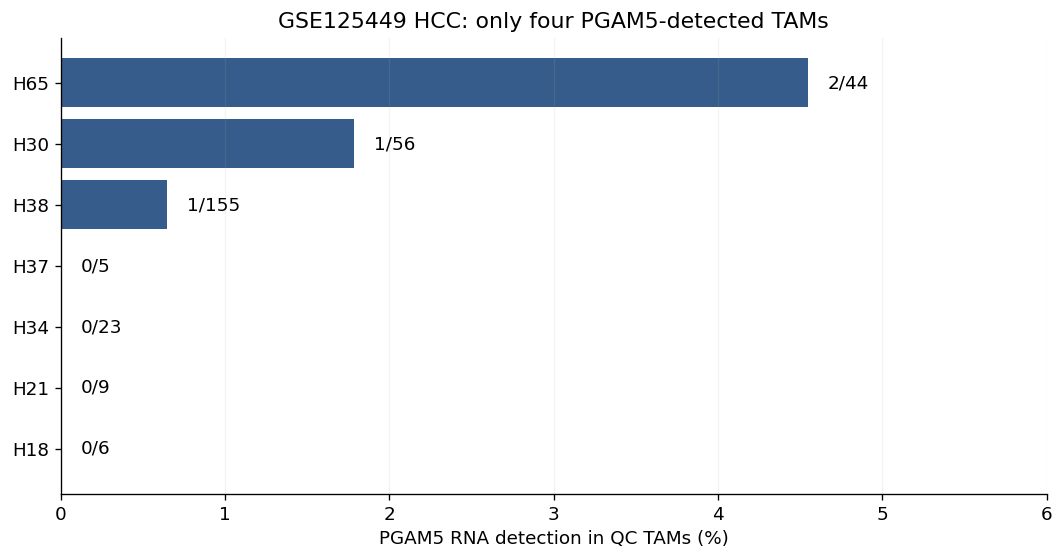

In [3]:
t=samples.sort_values('rate',ascending=True).reset_index(drop=True)
fig,ax=plt.subplots(figsize=(9,4.8))
ax.barh(t.paper_sample,t.rate*100,color=BLUE)
ax.set_xlim(0,6);ax.set_xlabel('PGAM5 RNA detection in QC TAMs (%)')
ax.set_title('GSE125449 HCC: only four PGAM5-detected TAMs')
for i,row in t.iterrows():ax.text(row.rate*100+.12,i,f"{row.PGAM5_positive}/{row.TAMs}",va='center')
ax.grid(axis='x',alpha=.15);fig.tight_layout();fig.savefig(R/'PGAM5_detection_by_HCC_sample.png');fig.savefig(R/'PGAM5_detection_by_HCC_sample.pdf');plt.show()


### 2. Requested Wilcoxon candidates

The following ranking is shown for reproducibility, not endorsed as a reliable signature. Against zero controls, approximate log2FC values near 29 reflect the small transform pseudocount and should not be interpreted as well-estimated billion-fold biological effects.


In [4]:
display(c[['gene','log2FC','FDR','detected_positive_cells','detected_undetected_cells','Fisher_two_sided_p','Fisher_BH_FDR']].head(20))
print('Candidates detected in only one positive cell:',int(c.detected_positive_cells.eq(1).sum()))
print('Candidates absent in all 294 controls:',int(c.detected_undetected_cells.eq(0).sum()))


,gene,log2FC,FDR,detected_positive_cells,detected_undetected_cells,Fisher_two_sided_p,Fisher_BH_FDR
names,,,,,,,
ENSG00000134207,SYT6,28.987627,5.799907e-15,1,0,0.013423,1.0
ENSG00000275202,RP11-156K23.3,28.987627,5.799907e-15,1,0,0.013423,1.0
ENSG00000171823,FBXL14,28.987627,5.799907e-15,1,0,0.013423,1.0
ENSG00000273361,RP11-378A13.2,28.987627,5.799907e-15,1,0,0.013423,1.0
ENSG00000274847,AC145212.2,28.987627,5.799907e-15,1,0,0.013423,1.0
ENSG00000111199,TRPV4,28.987627,5.799907e-15,1,0,0.013423,1.0
ENSG00000178445,GLDC,28.474325,5.799907e-15,1,0,0.013423,1.0
ENSG00000106459,NRF1,28.245134,5.799907e-15,1,0,0.013423,1.0
ENSG00000236256,DIAPH2-AS1,28.245134,5.799907e-15,1,0,0.013423,1.0


Candidates detected in only one positive cell: 225
Candidates absent in all 294 controls: 36


### 3. Small-group exact-detection sensitivity check

For a gene detected in one of four positives and none of 294 controls, the normal-approximation Wilcoxon p is approximately 1e-17, but the two-sided Fisher exact detection p is 4/298 = 0.01342. This illustrates that the tiny positive group and heavy ties can yield poorly calibrated asymptotic significance.

The tests address different aspects of expression: Fisher tests detection, while Wilcoxon ranks normalized expression. Their discrepancy, the single-cell support of many hits and the lack of exact-detection FDR support together prevent a robust signature claim.


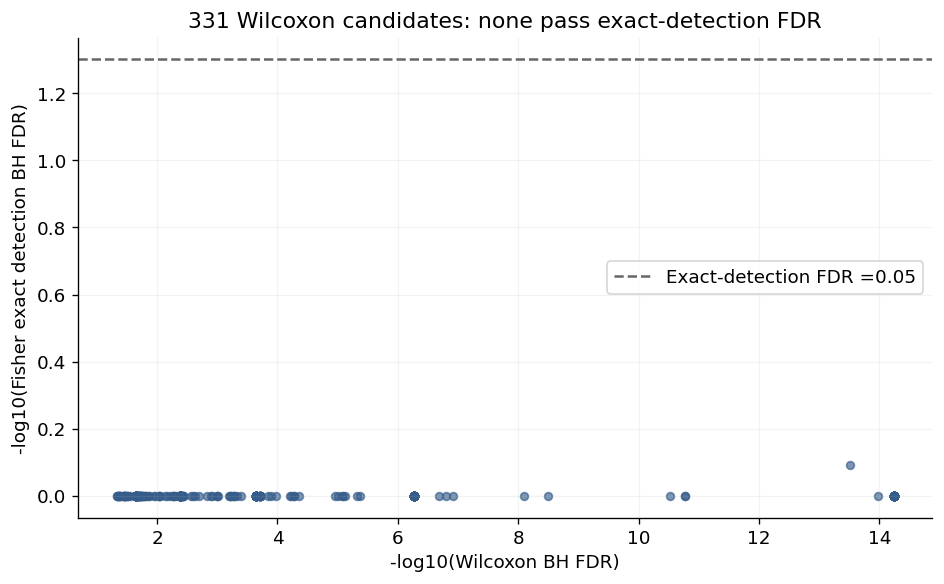

,value
test,Two-sided Fisher exact comparison of gene dete...
positive_cells,4
undetected_cells,294
Wilcoxon_up_candidates,331
Wilcoxon_candidates_passing_Fisher_FDR05,0
Fisher_FDR05_genes_excluding_PGAM5,0
candidate_genes_passing,[]
one_positive_zero_negative_exact_p,0.013423
one_positive_zero_negative_Wilcoxon_p,0.0


In [5]:
fig,ax=plt.subplots(figsize=(8,5))
ax.scatter(-np.log10(c.FDR.clip(lower=1e-300)),-np.log10(c.Fisher_BH_FDR.clip(lower=1e-300)),s=22,color=BLUE,alpha=.65)
ax.axhline(-np.log10(.05),color='#666666',ls='--',label='Exact-detection FDR =0.05')
ax.set_xlabel('-log10(Wilcoxon BH FDR)');ax.set_ylabel('-log10(Fisher exact detection BH FDR)')
ax.set_title('331 Wilcoxon candidates: none pass exact-detection FDR')
ax.legend();ax.grid(alpha=.15);fig.tight_layout();fig.savefig(R/'Wilcoxon_vs_exact_detection_FDR.png');fig.savefig(R/'Wilcoxon_vs_exact_detection_FDR.pdf');plt.show()
display(pd.Series(e,name='value').to_frame())


### 4. Cell annotation and dataset overlap

Original TAM labels have supporting macrophage marker expression. The overlap is an identifier check; no new dataset-independent validation is claimed.


In [6]:
qa=pd.read_csv(R/'TAM_marker_QA.csv');display(qa.pivot(index='gene',columns='group',values='fraction').round(3))
overlap=pd.read_csv(R/'GSE151530_sample_barcode_overlap_check.csv')
display(overlap.groupby('paper_sample').agg(QC_TAMs=('barcode','size'),matching_GSE151530_IDs=('cell_key_found_in_GSE151530','sum')))


group,PGAM5_detected,PGAM5_undetected
gene,,
ALB,0.25,0.493
APOA1,0.25,0.289
C1QA,0.75,0.551
C1QB,0.75,0.514
C1QC,0.75,0.500
CD3D,0.00,0.075
CD68,1.00,0.677
CSF1R,0.00,0.344
EPCAM,0.00,0.000


,QC_TAMs,matching_GSE151530_IDs
paper_sample,,
H18,6,6
H21,9,9
H30,56,56
H34,23,23
H37,5,5
H38,155,155
H65,44,44


## Takeaways

The same requested analysis is complete and its 331 upregulated candidates are retained. With only four positives, zero candidates supported by the supplementary exact-detection FDR, and identifier overlap with GSE151530, this cohort cannot establish a reliable independent PGAM5-positive macrophage signature.

No pathway enrichment, signature scoring or independent validation is claimed. A dataset with substantially more PGAM5-detected macrophages is preferable for further discovery.

### Reproduction

Download Set1/Set2 genes, barcodes, matrices and samples.txt plus family SOFT from GEO. Install dependencies listed in environment_versions.txt; run analyze_HCC.py then exact_detection_sensitivity.py. Scripts currently use /workspace/scratch/GSE125449, and the overlap check requires /workspace/scratch/GSE151530/all_cell_metadata.csv.gz. Change input paths on another machine. Retained result tables suffice to reproduce this notebook's figures; all input files and QC TAM counts remain in the cloud environment.
